In [5]:
import torch
import pytorch3d
print(f"PyTorch版本: {torch.__version__}")
print(f"PyTorch3D版本: {pytorch3d.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")

PyTorch版本: 2.9.1+cu128
PyTorch3D版本: 0.7.8
CUDA可用: True


迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


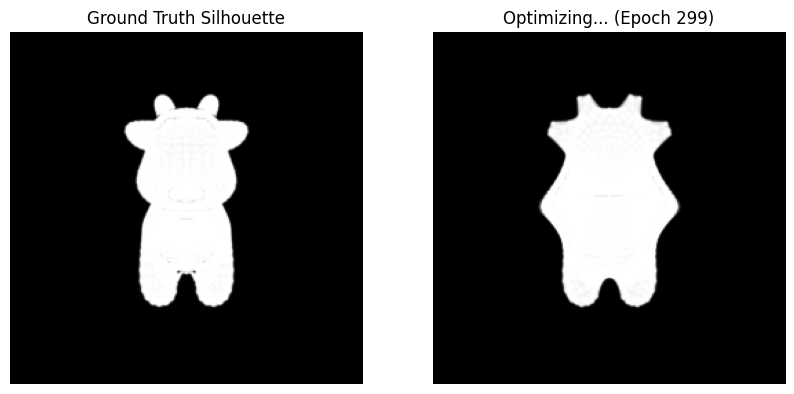

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj" # 使用绝对路径
if not os.path.exists(obj_path):
    raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0]) 
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device, 
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0], 
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras, 
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()
    
    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]
    
    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)
    
    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")
        
        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")
        
        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        
        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")
        
        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")
        
        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

📊 Epoch 499/500
   Total Loss:      0.004449
   Silhouette Loss: 0.001038
   Laplacian Loss:  0.003592
   Edge Loss:       0.002787
   Normal Loss:     0.025821
   Learning Rate:   0.000000
------------------------------------------------------------
💾 已保存: output_meshes_improved/mesh_epoch_499.obj



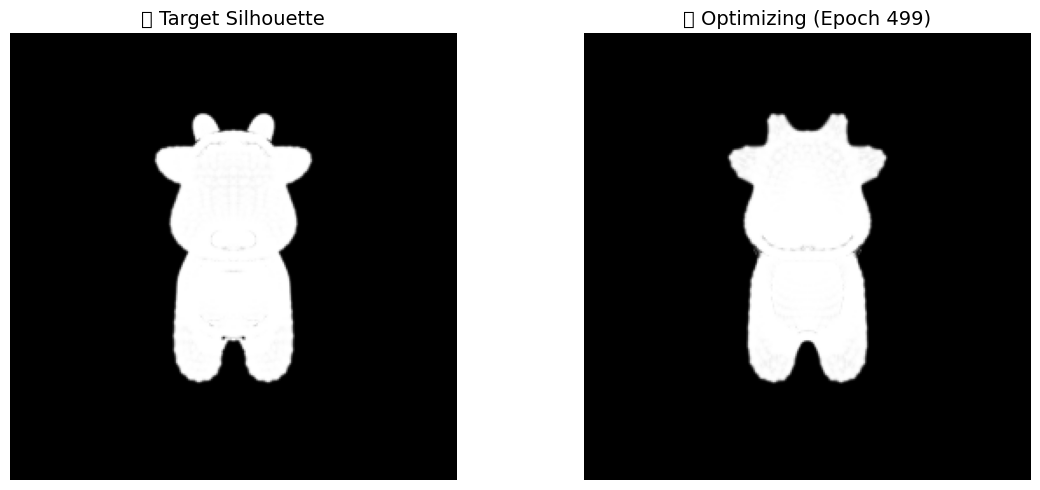


🎉 优化训练完成！
📁 所有模型已保存至: output_meshes_improved/
📊 最终 Total Loss: 0.004449
📊 最终 Silhouette Loss: 0.001038


/tmp/ipykernel_7591/2581787197.py:223: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/2581787197.py:223: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


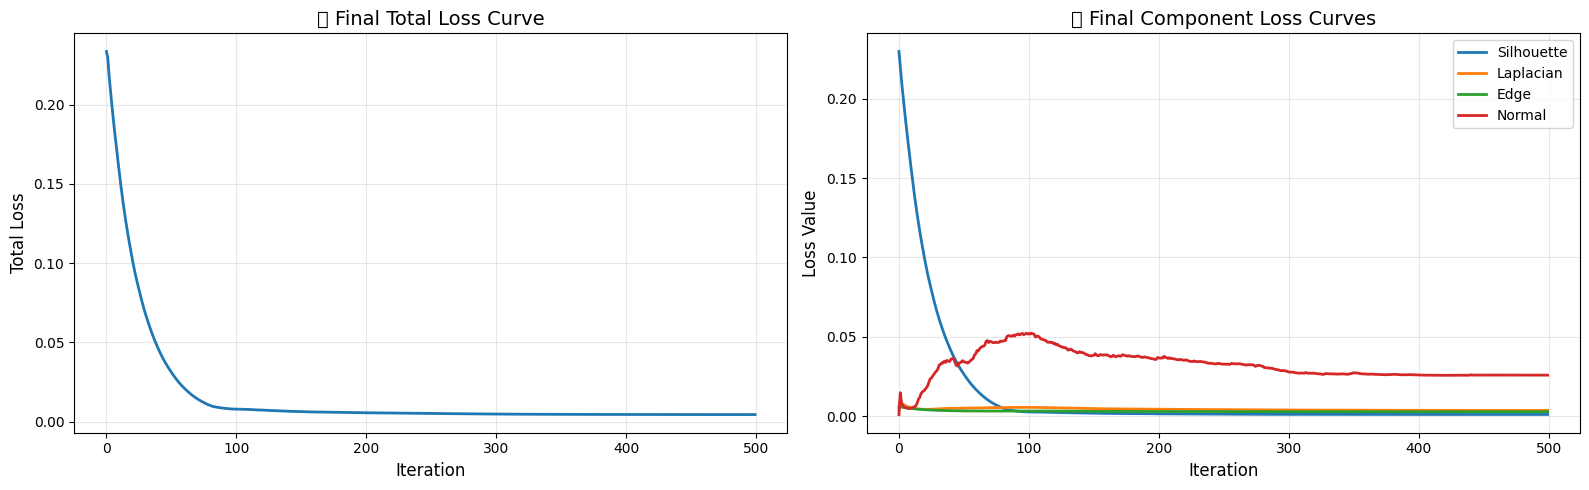

/tmp/ipykernel_7591/2581787197.py:237: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/2581787197.py:237: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


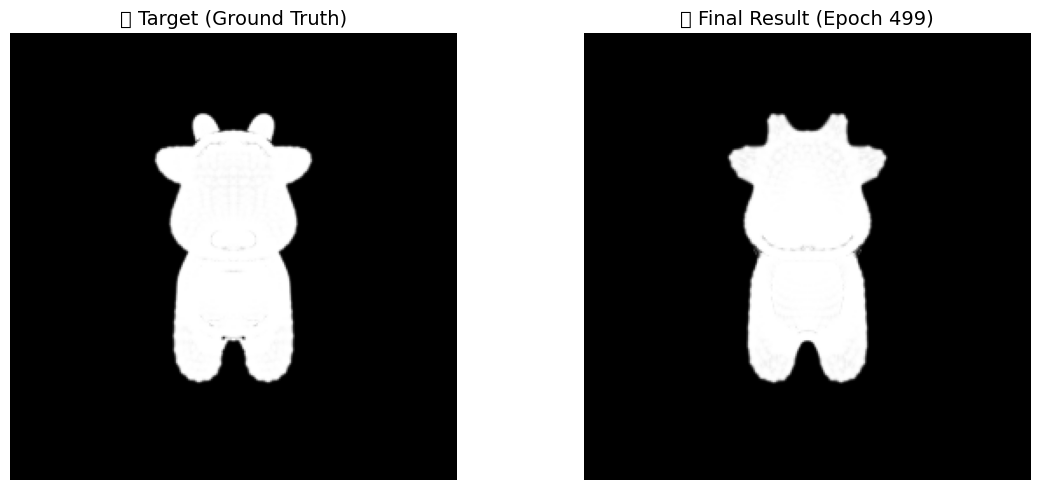

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    RasterizationSettings, 
    MeshRasterizer, 
    SoftSilhouetteShader, 
    BlendParams
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print(f"📦 PyTorch3D 版本: {pytorch3d.__version__}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"  # 根据你的实际路径调整
if not os.path.exists(obj_path):
    raise FileNotFoundError(f"❌ 未找到 {obj_path}，请检查路径！")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)

# 归一化处理
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型: {obj_path}")
print(f"   顶点数: {verts.shape[0]}, 面数: {faces_idx.shape[0]}")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

raster_settings = RasterizationSettings(
    image_size=256, 
    blur_radius=np.log(1./1e-4 - 1.)*1e-4,
    faces_per_pixel=50
)
rasterizer = MeshRasterizer(cameras=cameras, raster_settings=raster_settings)

blend_params = BlendParams(sigma=1e-4, gamma=1e-4)
shader = SoftSilhouetteShader(blend_params=blend_params)

# 渲染目标剪影
target_silhouette = shader(
    rasterizer(cow_mesh.extend(num_views)), 
    cow_mesh.extend(num_views)
)[..., 3]
print(f"✅ 已生成 {num_views} 个目标视角的剪影")

# ==================== 3. 初始化源模型（球体）====================
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
print(f"✅ 初始化球体网格: 顶点数 {src_mesh.verts_packed().shape[0]}")

# ==================== 4. 优化器配置（改进版）====================
epochs = 500  # 增加迭代次数
optimizer = torch.optim.Adam([deform_verts], lr=0.01)  # 使用Adam
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 正则化权重
w_laplacian = 0.8  # 从1.0降到0.8
w_edge = 0.1
w_normal = 0.01

# Loss历史记录
loss_history = {
    'total': [],
    'silhouette': [],
    'laplacian': [],
    'edge': [],
    'normal': []
}

# 创建保存目录
output_dir = "output_meshes_improved"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🎬 开始优化训练...\n")

# ==================== 5. 训练循环 ====================
for i in range(epochs):
    optimizer.zero_grad()
    
    # 应用形变
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 渲染当前预测剪影
    pred_silhouette = shader(
        rasterizer(new_src_mesh.extend(num_views)), 
        new_src_mesh.extend(num_views)
    )[..., 3]
    
    # 计算各项损失
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss_lap = mesh_laplacian_smoothing(new_src_mesh)
    loss_edge = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 总损失
    loss = loss_silhouette + w_laplacian * loss_lap + w_edge * loss_edge + w_normal * loss_norm
    
    # 反向传播
    loss.backward()
    optimizer.step()
    scheduler.step()  # 更新学习率
    
    # 记录loss
    loss_history['total'].append(loss.item())
    loss_history['silhouette'].append(loss_silhouette.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge.item())
    loss_history['normal'].append(loss_norm.item())
    
    # ==================== 可视化与保存 ====================
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"📊 Epoch {i:03d}/{epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f}")
        print(f"   Edge Loss:       {loss_edge.item():.6f}")
        print(f"   Normal Loss:     {loss_norm.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        # 保存模型
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"💾 已保存: {save_path}\n")
        
        # 可视化剪影对比
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        axes[0].set_title("🎯 Target Silhouette", fontsize=14)
        axes[0].axis("off")
        
        axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        axes[1].set_title(f"🔄 Optimizing (Epoch {i})", fontsize=14)
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()
        
        # 每100步绘制loss曲线
        if i % 100 == 0 and i > 0:
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            # 总Loss曲线
            axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
            axes[0].set_xlabel('Iteration', fontsize=12)
            axes[0].set_ylabel('Total Loss', fontsize=12)
            axes[0].set_title('📈 Total Loss Curve', fontsize=14)
            axes[0].grid(True, alpha=0.3)
            
            # 各分项Loss曲线
            axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
            axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
            axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
            axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
            axes[1].set_xlabel('Iteration', fontsize=12)
            axes[1].set_ylabel('Loss Value', fontsize=12)
            axes[1].set_title('📊 Component Loss Curves', fontsize=14)
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

# ==================== 训练完成 ====================
print("\n" + "="*60)
print("🎉 优化训练完成！")
print(f"📁 所有模型已保存至: {output_dir}/")
print(f"📊 最终 Total Loss: {loss_history['total'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print("="*60)

# ==================== 最终Loss曲线 ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Total Loss', fontsize=12)
axes[0].set_title('📈 Final Total Loss Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Loss Value', fontsize=12)
axes[1].set_title('📊 Final Component Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== 最终对比展示 ====================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
axes[0].set_title("🎯 Target (Ground Truth)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
axes[1].set_title("✨ Final Result (Epoch 499)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

📊 Stage 2 (Smoothing) - Epoch 499/500
   Total Loss:      0.009967
   Silhouette Loss: 0.001870
   Laplacian Loss:  0.002929 (weight: 2.5)
   Edge Loss:       0.002656
   Normal Loss:     0.018793
   Learning Rate:   0.000000
------------------------------------------------------------
💾 已保存: output_meshes_smooth/mesh_epoch_499.obj



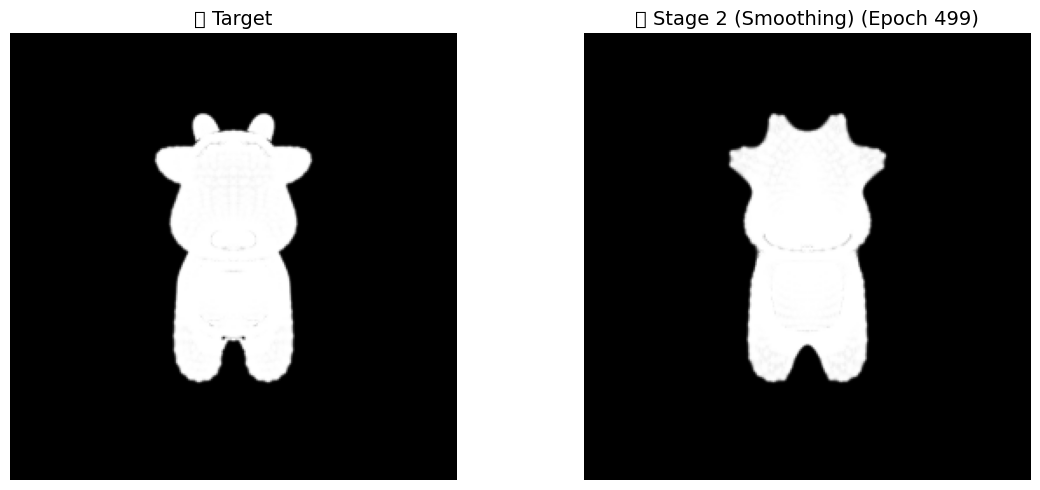

/tmp/ipykernel_7591/222110116.py:175: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


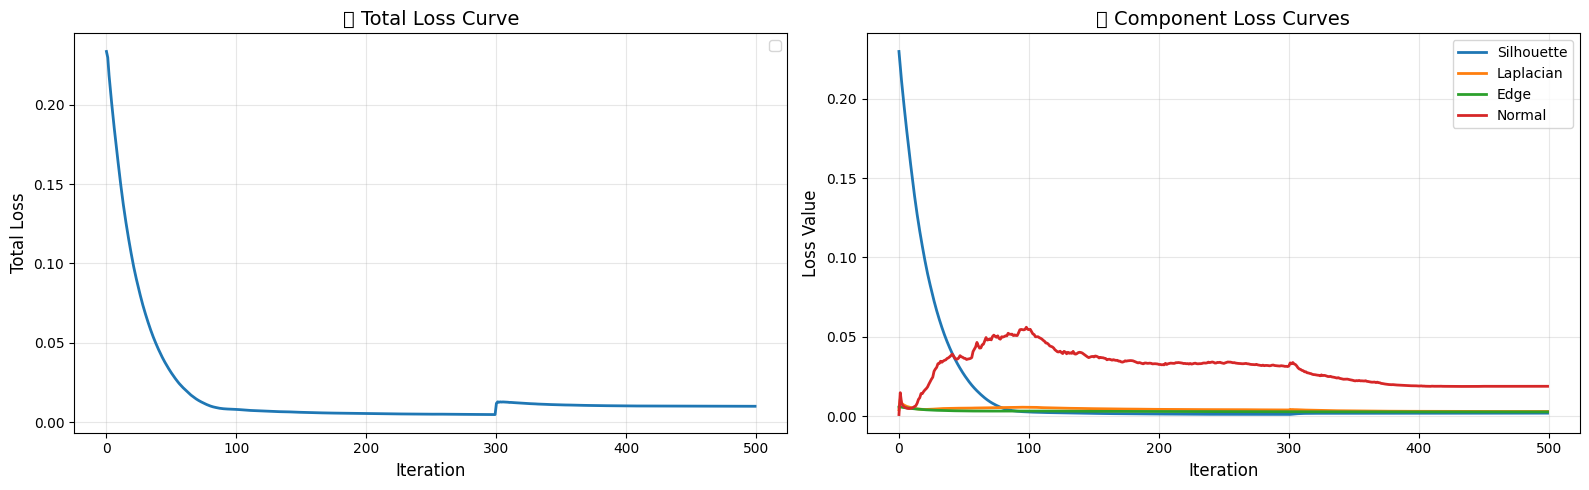

/tmp/ipykernel_7591/222110116.py:210: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



🎉 两阶段优化完成！
📁 所有模型已保存至: output_meshes_smooth/
📊 最终 Total Loss: 0.009967
📊 最终 Silhouette Loss: 0.001870
📊 最终 Laplacian Loss: 0.002929


/tmp/ipykernel_7591/222110116.py:210: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


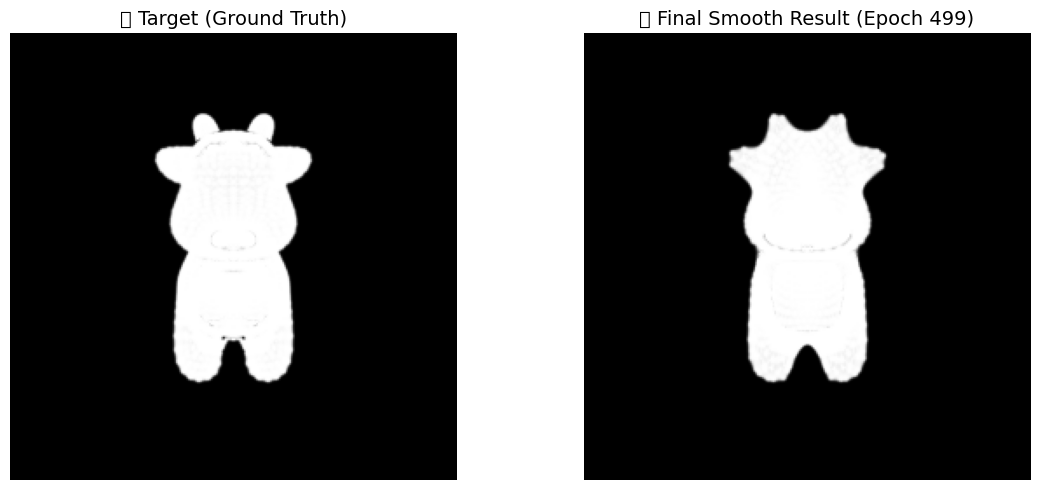

In [12]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    RasterizationSettings, 
    MeshRasterizer, 
    SoftSilhouetteShader, 
    BlendParams
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print(f"📦 PyTorch3D 版本: {pytorch3d.__version__}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"
if not os.path.exists(obj_path):
    raise FileNotFoundError(f"❌ 未找到 {obj_path}，请检查路径！")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
raster_settings = RasterizationSettings(
    image_size=256, 
    blur_radius=np.log(1./1e-4 - 1.)*1e-4,
    faces_per_pixel=50
)
rasterizer = MeshRasterizer(cameras=cameras, raster_settings=raster_settings)
blend_params = BlendParams(sigma=1e-4, gamma=1e-4)
shader = SoftSilhouetteShader(blend_params=blend_params)

target_silhouette = shader(
    rasterizer(cow_mesh.extend(num_views)), 
    cow_mesh.extend(num_views)
)[..., 3]
print(f"✅ 已生成 {num_views} 个目标剪影")

# ==================== 3. 初始化源模型 ====================
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
print(f"✅ 初始化球体网格")

# ==================== 4. 两阶段训练配置 ====================
# 阶段1：快速拟合形状（300步）
# 阶段2：精细光滑化（200步）

stage1_epochs = 300
stage2_epochs = 200
total_epochs = stage1_epochs + stage2_epochs

optimizer = torch.optim.Adam([deform_verts], lr=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

loss_history = {
    'total': [], 'silhouette': [], 'laplacian': [], 'edge': [], 'normal': []
}

output_dir = "output_meshes_smooth"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🎬 阶段1: 快速形状拟合 (Epoch 0-299)")
print("🎬 阶段2: 精细光滑化 (Epoch 300-499)")
print("="*60 + "\n")

# ==================== 5. 训练循环 ====================
for i in range(total_epochs):
    optimizer.zero_grad()
    
    # 🔥 动态调整权重：阶段1注重形状，阶段2注重光滑
    if i < stage1_epochs:
        # 阶段1：形状拟合
        w_laplacian = 0.8
        w_edge = 0.1
        w_normal = 0.01
        stage_name = "Stage 1 (Shape Fitting)"
    else:
        # 阶段2：光滑优化
        w_laplacian = 2.5  # 大幅提高光滑权重
        w_edge = 0.15
        w_normal = 0.02
        stage_name = "Stage 2 (Smoothing)"
    
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    pred_silhouette = shader(
        rasterizer(new_src_mesh.extend(num_views)), 
        new_src_mesh.extend(num_views)
    )[..., 3]
    
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss_lap = mesh_laplacian_smoothing(new_src_mesh)
    loss_edge = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    loss = loss_silhouette + w_laplacian * loss_lap + w_edge * loss_edge + w_normal * loss_norm
    
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    loss_history['total'].append(loss.item())
    loss_history['silhouette'].append(loss_silhouette.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge.item())
    loss_history['normal'].append(loss_norm.item())
    
    # ==================== 可视化 ====================
    if i % 20 == 0 or i == total_epochs - 1 or i == stage1_epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"📊 {stage_name} - Epoch {i:03d}/{total_epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f} (weight: {w_laplacian})")
        print(f"   Edge Loss:       {loss_edge.item():.6f}")
        print(f"   Normal Loss:     {loss_norm.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"💾 已保存: {save_path}\n")
        
        # 可视化
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        axes[0].set_title("🎯 Target", fontsize=14)
        axes[0].axis("off")
        axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        axes[1].set_title(f"🔄 {stage_name} (Epoch {i})", fontsize=14)
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
        
        # 阶段转换时绘制Loss曲线
        if i == stage1_epochs - 1 or i == total_epochs - 1:
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
            if i == stage1_epochs - 1:
                axes[0].axvline(x=stage1_epochs, color='red', linestyle='--', label='Stage Transition')
            axes[0].set_xlabel('Iteration', fontsize=12)
            axes[0].set_ylabel('Total Loss', fontsize=12)
            axes[0].set_title('📈 Total Loss Curve', fontsize=14)
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
            axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
            axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
            axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
            if i == stage1_epochs - 1:
                axes[1].axvline(x=stage1_epochs, color='red', linestyle='--', label='Stage Transition')
            axes[1].set_xlabel('Iteration', fontsize=12)
            axes[1].set_ylabel('Loss Value', fontsize=12)
            axes[1].set_title('📊 Component Loss Curves', fontsize=14)
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

# ==================== 完成 ====================
print("\n" + "="*60)
print("🎉 两阶段优化完成！")
print(f"📁 所有模型已保存至: {output_dir}/")
print(f"📊 最终 Total Loss: {loss_history['total'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print(f"📊 最终 Laplacian Loss: {loss_history['laplacian'][-1]:.6f}")
print("="*60)

# 最终对比
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
axes[0].set_title("🎯 Target (Ground Truth)", fontsize=14)
axes[0].axis("off")
axes[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
axes[1].set_title("✨ Final Smooth Result (Epoch 499)", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

📊 Epoch 499/500
   Total Loss:      0.009521
   RGB Loss:        0.000573
   Silhouette Loss: 0.001225
   Laplacian Loss:  0.004238
   Edge Loss:       0.003184
   Normal Loss:     0.030130
   Learning Rate:   0.000000
------------------------------------------------------------
💾 已保存: output_meshes_textured/mesh_epoch_499.obj



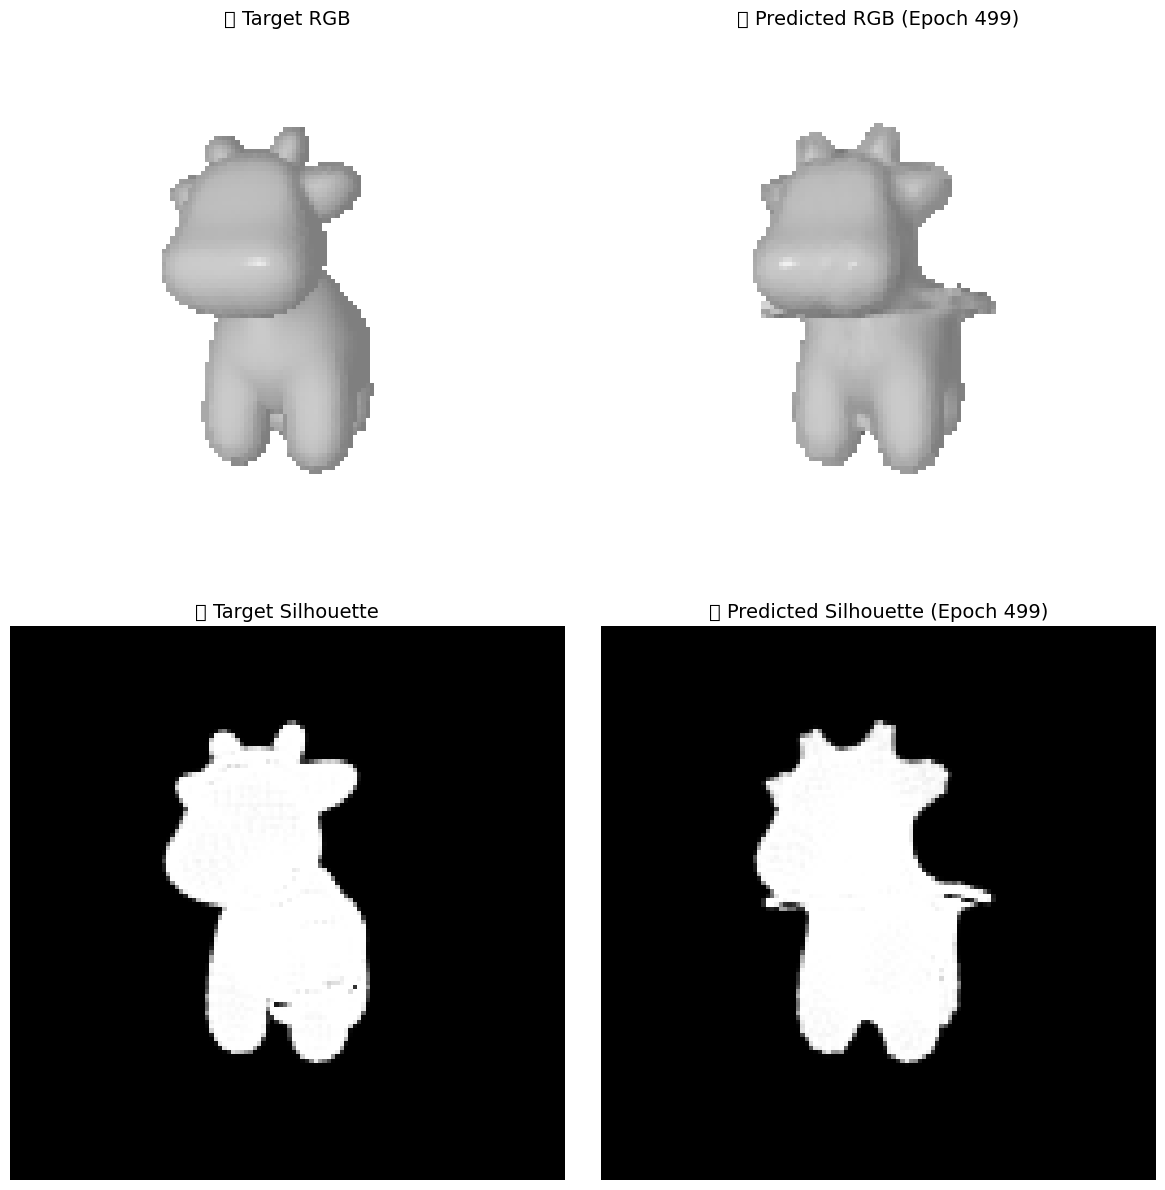


🎉 纹理优化完成！
📁 所有模型已保存至: output_meshes_textured/
📊 最终 Total Loss: 0.009521
📊 最终 RGB Loss: 0.000573
📊 最终 Silhouette Loss: 0.001225


/tmp/ipykernel_7591/2694161998.py:328: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/2694161998.py:328: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


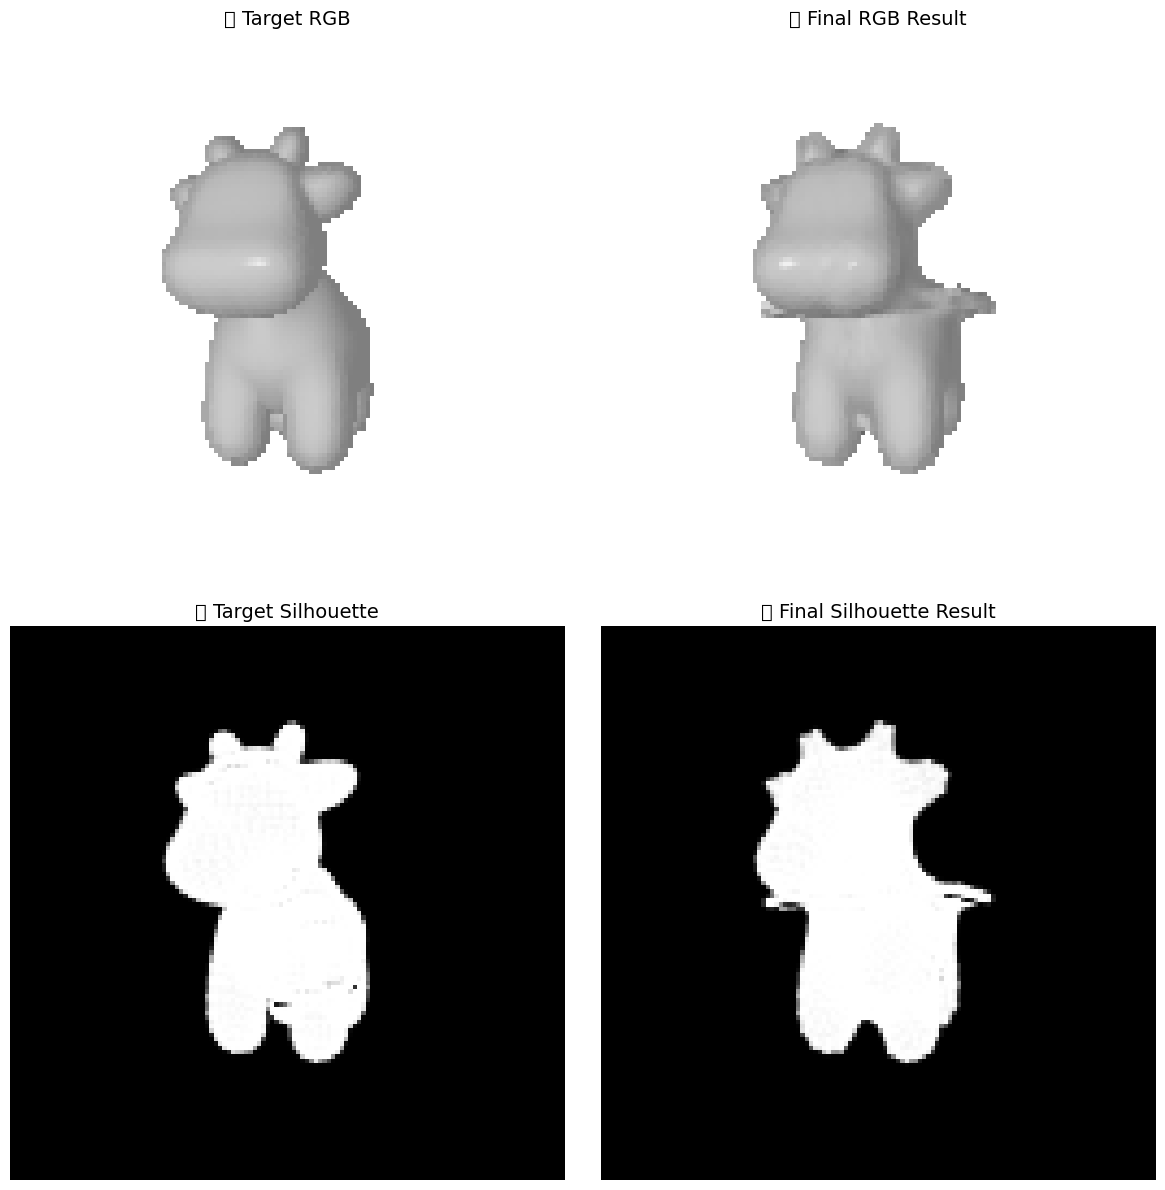

In [13]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings, 
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    BlendParams,
    TexturesVertex
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print(f"📦 PyTorch3D 版本: {pytorch3d.__version__}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"  # 根据你的实际路径调整
if not os.path.exists(obj_path):
    raise FileNotFoundError(f"❌ 未找到 {obj_path}")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# 🔥 添加光照（纹理渲染必需）
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# 软光栅化设置
sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=128,  # 降低分辨率加快速度，可改为256
    blur_radius=np.log(1./1e-4 - 1.)*sigma,
    faces_per_pixel=50,
    perspective_correct=False
)

# 🔥 RGB渲染器 - 使用Phong着色
renderer_rgb = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
)

# 剪影渲染器
renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftSilhouetteShader()
)

# ==================== 3. 生成目标数据 ====================
print("🎨 生成目标RGB图像和剪影...")

# 给cow mesh添加一个简单的白色纹理用于演示
verts_rgb_white = torch.ones_like(verts).unsqueeze(0)  # (1, V, 3)
cow_mesh.textures = TexturesVertex(verts_features=verts_rgb_white)

# 渲染目标RGB图像
target_rgb_images = renderer_rgb(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_rgb = [target_rgb_images[i, ..., :3] for i in range(num_views)]

# 渲染目标剪影
target_silhouette_images = renderer_silhouette(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_silhouette = [target_silhouette_images[i, ..., 3] for i in range(num_views)]

print(f"✅ 已生成 {num_views} 个目标视角的RGB和剪影")

# 可视化目标数据
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(target_rgb[i*5].cpu().numpy())
    axes[0, i].set_title(f"RGB View {i*5}")
    axes[0, i].axis("off")
    axes[1, i].imshow(target_silhouette[i*5].cpu().numpy(), cmap='gray')
    axes[1, i].set_title(f"Silhouette View {i*5}")
    axes[1, i].axis("off")
plt.suptitle("🎯 Target Dataset", fontsize=16)
plt.tight_layout()
plt.show()

# ==================== 4. 初始化源模型（球体）====================
src_mesh = ico_sphere(4, device)
verts_shape = src_mesh.verts_packed().shape
print(f"✅ 初始化球体: {verts_shape[0]} 个顶点")

# 🔥 两个可学习参数
deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)  # 初始灰色

# ==================== 5. 优化器配置 ====================
epochs = 500
num_views_per_iteration = 2  # 每次随机选2个视角

optimizer = torch.optim.Adam([deform_verts, sphere_verts_rgb], lr=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 权重
w_rgb = 1.0          # RGB颜色匹配
w_silhouette = 1.0   # 轮廓匹配
w_laplacian = 1.0    # 平滑
w_edge = 1.0         # 边长
w_normal = 0.01      # 法线一致

loss_history = {
    'total': [], 'rgb': [], 'silhouette': [], 
    'laplacian': [], 'edge': [], 'normal': []
}

output_dir = "output_meshes_textured"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🎬 开始纹理优化训练...\n")

# ==================== 6. 训练循环 ====================
for i in range(epochs):
    optimizer.zero_grad()
    
    # 应用形变
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 🔥 添加纹理
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb)
    
    # 初始化损失
    loss_rgb_sum = torch.tensor(0.0, device=device)
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    
    # 随机选择2个视角进行优化
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]
    
    for j in selected_views:
        # 渲染RGB图像
        images_predicted = renderer_rgb(
            new_src_mesh, 
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        predicted_rgb = images_predicted[0, ..., :3]
        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()
        loss_rgb_sum += loss_rgb / num_views_per_iteration
        
        # 渲染剪影
        silhouette_predicted = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        predicted_silhouette = silhouette_predicted[0, ..., 3]
        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / num_views_per_iteration
    
    # 正则化损失
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 总损失
    loss = (w_rgb * loss_rgb_sum + 
            w_silhouette * loss_silhouette_sum + 
            w_laplacian * loss_lap + 
            w_edge * loss_edge_loss + 
            w_normal * loss_norm)
    
    # 反向传播
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    # 记录
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(loss_rgb_sum.item())
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    # ==================== 可视化 ====================
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"📊 Epoch {i:03d}/{epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   RGB Loss:        {loss_rgb_sum.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette_sum.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f}")
        print(f"   Edge Loss:       {loss_edge_loss.item():.6f}")
        print(f"   Normal Loss:     {loss_norm.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        # 保存模型
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"💾 已保存: {save_path}\n")
        
        # 渲染当前结果用于可视化
        with torch.no_grad():
            pred_img = renderer_rgb(
                new_src_mesh, 
                cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
                lights=lights
            )
            pred_sil = renderer_silhouette(
                new_src_mesh,
                cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
                lights=lights
            )
        
        # 可视化：RGB对比 + 剪影对比
        fig, axes = plt.subplots(2, 2, figsize=(12, 12))
        
        # RGB对比
        axes[0, 0].imshow(target_rgb[1].cpu().numpy())
        axes[0, 0].set_title("🎯 Target RGB", fontsize=14)
        axes[0, 0].axis("off")
        
        axes[0, 1].imshow(pred_img[0, ..., :3].cpu().numpy())
        axes[0, 1].set_title(f"🔄 Predicted RGB (Epoch {i})", fontsize=14)
        axes[0, 1].axis("off")
        
        # 剪影对比
        axes[1, 0].imshow(target_silhouette[1].cpu().numpy(), cmap='gray')
        axes[1, 0].set_title("🎯 Target Silhouette", fontsize=14)
        axes[1, 0].axis("off")
        
        axes[1, 1].imshow(pred_sil[0, ..., 3].cpu().numpy(), cmap='gray')
        axes[1, 1].set_title(f"🔄 Predicted Silhouette (Epoch {i})", fontsize=14)
        axes[1, 1].axis("off")
        
        plt.tight_layout()
        plt.show()
        
        # 每100步绘制loss曲线
        if i % 100 == 0 and i > 0:
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            axes[0].plot(loss_history['total'], linewidth=2, color='#1f77b4')
            axes[0].set_xlabel('Iteration', fontsize=12)
            axes[0].set_ylabel('Total Loss', fontsize=12)
            axes[0].set_title('📈 Total Loss Curve', fontsize=14)
            axes[0].grid(True, alpha=0.3)
            
            axes[1].plot(loss_history['rgb'], label='RGB', linewidth=2)
            axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
            axes[1].plot(loss_history['laplacian'], label='Laplacian', linewidth=2)
            axes[1].plot(loss_history['edge'], label='Edge', linewidth=2)
            axes[1].plot(loss_history['normal'], label='Normal', linewidth=2)
            axes[1].set_xlabel('Iteration', fontsize=12)
            axes[1].set_ylabel('Loss Value', fontsize=12)
            axes[1].set_title('📊 Component Loss Curves', fontsize=14)
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

# ==================== 完成 ====================
print("\n" + "="*60)
print("🎉 纹理优化完成！")
print(f"📁 所有模型已保存至: {output_dir}/")
print(f"📊 最终 Total Loss: {loss_history['total'][-1]:.6f}")
print(f"📊 最终 RGB Loss: {loss_history['rgb'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print("="*60)

# 最终结果展示
with torch.no_grad():
    final_rgb = renderer_rgb(
        new_src_mesh, 
        cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
        lights=lights
    )
    final_sil = renderer_silhouette(
        new_src_mesh,
        cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
        lights=lights
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(target_rgb[1].cpu().numpy())
axes[0, 0].set_title("🎯 Target RGB", fontsize=14)
axes[0, 0].axis("off")

axes[0, 1].imshow(final_rgb[0, ..., :3].cpu().numpy())
axes[0, 1].set_title("✨ Final RGB Result", fontsize=14)
axes[0, 1].axis("off")

axes[1, 0].imshow(target_silhouette[1].cpu().numpy(), cmap='gray')
axes[1, 0].set_title("🎯 Target Silhouette", fontsize=14)
axes[1, 0].axis("off")

axes[1, 1].imshow(final_sil[0, ..., 3].cpu().numpy(), cmap='gray')
axes[1, 1].set_title("✨ Final Silhouette Result", fontsize=14)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

📊 阶段2 - Epoch 599/600
   Total Loss:      0.015975
   RGB Loss:        0.003367
   Silhouette Loss: 0.002308
   Laplacian Loss:  0.004547
   Learning Rate:   0.000000
------------------------------------------------------------


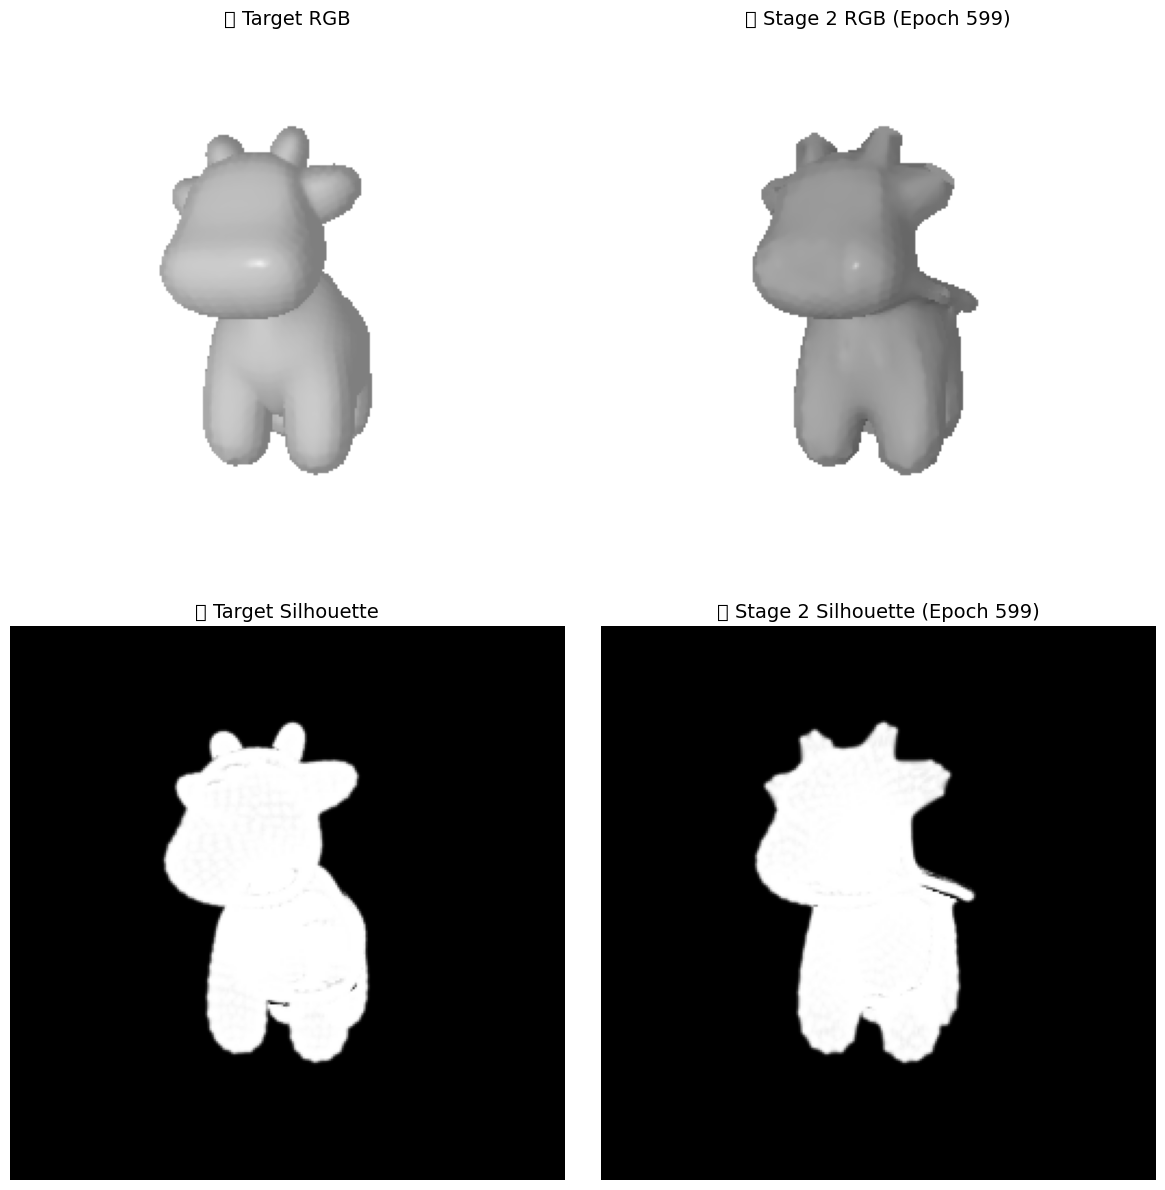


🎉 两阶段纹理优化完成！
📁 所有模型已保存至: output_meshes_textured_v2/
📊 最终 Total Loss: 0.015975
📊 最终 RGB Loss: 0.003367
📊 最终 Silhouette Loss: 0.002308


/tmp/ipykernel_7591/1713606959.py:351: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/1713606959.py:351: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


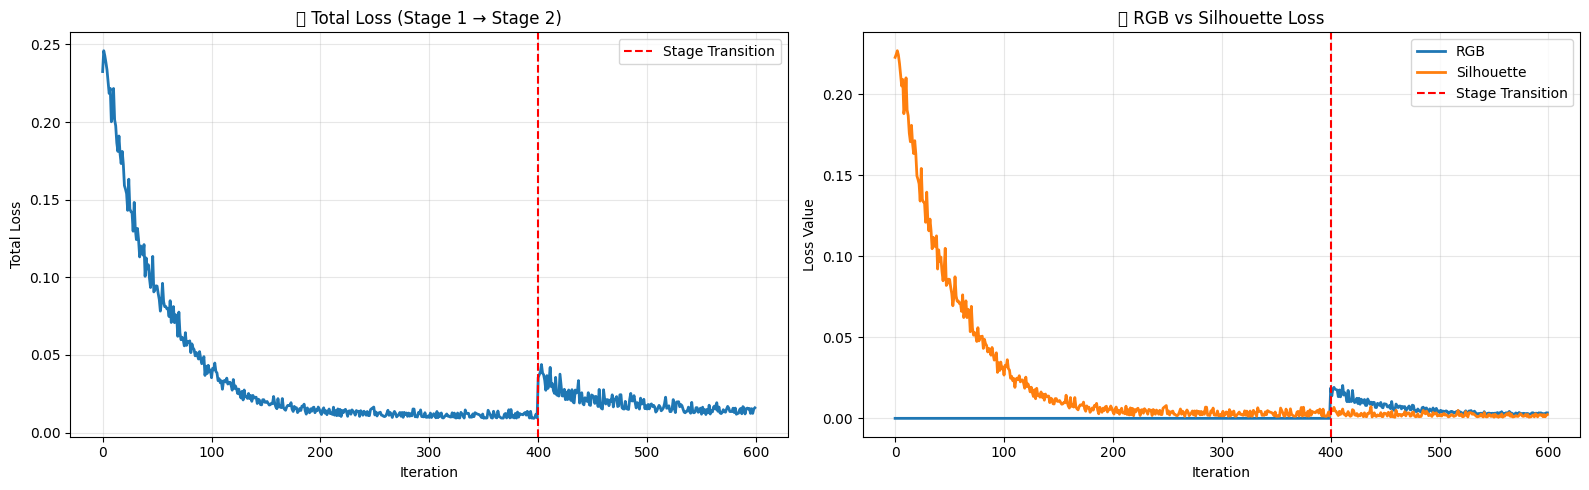

In [15]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings, 
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    TexturesVertex
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print(f"📦 PyTorch3D 版本: {pytorch3d.__version__}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"  # 根据你的实际路径调整
if not os.path.exists(obj_path):
    raise FileNotFoundError(f"❌ 未找到 {obj_path}")

verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# 🔥 提高分辨率到256
sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=256,  # 从128提高到256
    blur_radius=np.log(1./1e-4 - 1.)*sigma,
    faces_per_pixel=50,
    perspective_correct=False
)

renderer_rgb = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftSilhouetteShader()
)

# ==================== 3. 生成目标数据 ====================
print("🎨 生成目标RGB图像和剪影...")

verts_rgb_white = torch.ones_like(verts).unsqueeze(0)
cow_mesh.textures = TexturesVertex(verts_features=verts_rgb_white)

target_rgb_images = renderer_rgb(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_rgb = [target_rgb_images[i, ..., :3] for i in range(num_views)]

target_silhouette_images = renderer_silhouette(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_silhouette = [target_silhouette_images[i, ..., 3] for i in range(num_views)]

print(f"✅ 已生成 {num_views} 个目标视角 (分辨率: 256x256)")

# ==================== 4. 初始化源模型 ====================
src_mesh = ico_sphere(4, device)
verts_shape = src_mesh.verts_packed().shape
print(f"✅ 初始化球体: {verts_shape[0]} 个顶点")

deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# ==================== 5. 两阶段训练配置 ====================
stage1_epochs = 400  # 阶段1：纯形状优化
stage2_epochs = 200  # 阶段2：形状+纹理优化
total_epochs = stage1_epochs + stage2_epochs

num_views_per_iteration = 2

# 🔥 关键：阶段1只优化形状
optimizer_stage1 = torch.optim.Adam([deform_verts], lr=0.01)
scheduler_stage1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_stage1, T_max=stage1_epochs)

loss_history = {
    'total': [], 'rgb': [], 'silhouette': [], 
    'laplacian': [], 'edge': [], 'normal': []
}

output_dir = "output_meshes_textured_v2"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🎬 阶段1: 纯形状优化 (Epoch 0-399)")
print("🎬 阶段2: 形状+纹理优化 (Epoch 400-599)")
print("="*60 + "\n")

# ==================== 6. 阶段1：纯形状优化 ====================
print("🔷 开始阶段1：专注形状拟合...")

for i in range(stage1_epochs):
    optimizer_stage1.zero_grad()
    
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 阶段1：只计算silhouette loss
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]
    
    for j in selected_views:
        silhouette_predicted = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        predicted_silhouette = silhouette_predicted[0, ..., 3]
        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / num_views_per_iteration
    
    # 正则化
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 阶段1总损失：只有silhouette和正则化
    loss = (1.0 * loss_silhouette_sum + 
            1.0 * loss_lap + 
            1.0 * loss_edge_loss + 
            0.01 * loss_norm)
    
    loss.backward()
    optimizer_stage1.step()
    scheduler_stage1.step()
    
    # 记录
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(0.0)  # 阶段1没有RGB
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    # 可视化
    if i % 20 == 0 or i == stage1_epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer_stage1.param_groups[0]['lr']
        print(f"📊 阶段1 - Epoch {i:03d}/{stage1_epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette_sum.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        # 保存模型
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_stage1_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        
        # 可视化
        with torch.no_grad():
            pred_sil = renderer_silhouette(
                new_src_mesh,
                cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
                lights=lights
            )
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(target_silhouette[1].cpu().numpy(), cmap='gray')
        axes[0].set_title("🎯 Target Silhouette", fontsize=14)
        axes[0].axis("off")
        
        axes[1].imshow(pred_sil[0, ..., 3].cpu().numpy(), cmap='gray')
        axes[1].set_title(f"🔷 Stage 1 (Epoch {i})", fontsize=14)
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()

print("\n✅ 阶段1完成！形状已基本拟合。")
print("🔶 开始阶段2：纹理优化...\n")

# ==================== 7. 阶段2：形状+纹理优化 ====================
# 🔥 阶段2：同时优化形状和纹理
optimizer_stage2 = torch.optim.Adam([deform_verts, sphere_verts_rgb], lr=0.005)  # 更小的学习率
scheduler_stage2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_stage2, T_max=stage2_epochs)

for i in range(stage2_epochs):
    optimizer_stage2.zero_grad()
    
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb)
    
    loss_rgb_sum = torch.tensor(0.0, device=device)
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]
    
    for j in selected_views:
        # RGB
        images_predicted = renderer_rgb(
            new_src_mesh, 
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        predicted_rgb = images_predicted[0, ..., :3]
        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()
        loss_rgb_sum += loss_rgb / num_views_per_iteration
        
        # Silhouette
        silhouette_predicted = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        predicted_silhouette = silhouette_predicted[0, ..., 3]
        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / num_views_per_iteration
    
    # 正则化
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 🔥 阶段2：silhouette权重更高，确保形状不退化
    loss = (1.0 * loss_rgb_sum + 
            2.0 * loss_silhouette_sum +  # 提高silhouette权重
            1.0 * loss_lap + 
            1.0 * loss_edge_loss + 
            0.01 * loss_norm)
    
    loss.backward()
    optimizer_stage2.step()
    scheduler_stage2.step()
    
    # 记录
    epoch_num = stage1_epochs + i
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(loss_rgb_sum.item())
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    # 可视化
    if i % 20 == 0 or i == stage2_epochs - 1:
        clear_output(wait=True)
        
        current_lr = optimizer_stage2.param_groups[0]['lr']
        print(f"📊 阶段2 - Epoch {epoch_num:03d}/{total_epochs}")
        print(f"   Total Loss:      {loss.item():.6f}")
        print(f"   RGB Loss:        {loss_rgb_sum.item():.6f}")
        print(f"   Silhouette Loss: {loss_silhouette_sum.item():.6f}")
        print(f"   Laplacian Loss:  {loss_lap.item():.6f}")
        print(f"   Learning Rate:   {current_lr:.6f}")
        print("-" * 60)
        
        # 保存
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]
        save_path = os.path.join(output_dir, f"mesh_stage2_epoch_{epoch_num:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        
        # 可视化
        with torch.no_grad():
            pred_rgb = renderer_rgb(
                new_src_mesh, 
                cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
                lights=lights
            )
            pred_sil = renderer_silhouette(
                new_src_mesh,
                cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]),
                lights=lights
            )
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 12))
        
        axes[0, 0].imshow(target_rgb[1].cpu().numpy())
        axes[0, 0].set_title("🎯 Target RGB", fontsize=14)
        axes[0, 0].axis("off")
        
        axes[0, 1].imshow(pred_rgb[0, ..., :3].cpu().numpy())
        axes[0, 1].set_title(f"🔶 Stage 2 RGB (Epoch {epoch_num})", fontsize=14)
        axes[0, 1].axis("off")
        
        axes[1, 0].imshow(target_silhouette[1].cpu().numpy(), cmap='gray')
        axes[1, 0].set_title("🎯 Target Silhouette", fontsize=14)
        axes[1, 0].axis("off")
        
        axes[1, 1].imshow(pred_sil[0, ..., 3].cpu().numpy(), cmap='gray')
        axes[1, 1].set_title(f"🔶 Stage 2 Silhouette (Epoch {epoch_num})", fontsize=14)
        axes[1, 1].axis("off")
        
        plt.tight_layout()
        plt.show()

# ==================== 完成 ====================
print("\n" + "="*60)
print("🎉 两阶段纹理优化完成！")
print(f"📁 所有模型已保存至: {output_dir}/")
print(f"📊 最终 Total Loss: {loss_history['total'][-1]:.6f}")
print(f"📊 最终 RGB Loss: {loss_history['rgb'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print("="*60)

# Loss曲线
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(loss_history['total'], linewidth=2)
axes[0].axvline(x=stage1_epochs, color='red', linestyle='--', label='Stage Transition')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('📈 Total Loss (Stage 1 → Stage 2)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history['rgb'], label='RGB', linewidth=2)
axes[1].plot(loss_history['silhouette'], label='Silhouette', linewidth=2)
axes[1].axvline(x=stage1_epochs, color='red', linestyle='--', label='Stage Transition')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss Value')
axes[1].set_title('📊 RGB vs Silhouette Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

🔸 阶段3 - Epoch 1099/1100 | Loss: 0.011707 | RGB: 0.000646 | Sil: 0.000992

🎉 三阶段优化完成！
📁 模型: output_meshes_textured_v3/
📊 最终 RGB Loss: 0.000646
📊 最终 Silhouette Loss: 0.000992


/tmp/ipykernel_7591/3786140574.py:307: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7591/3786140574.py:307: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


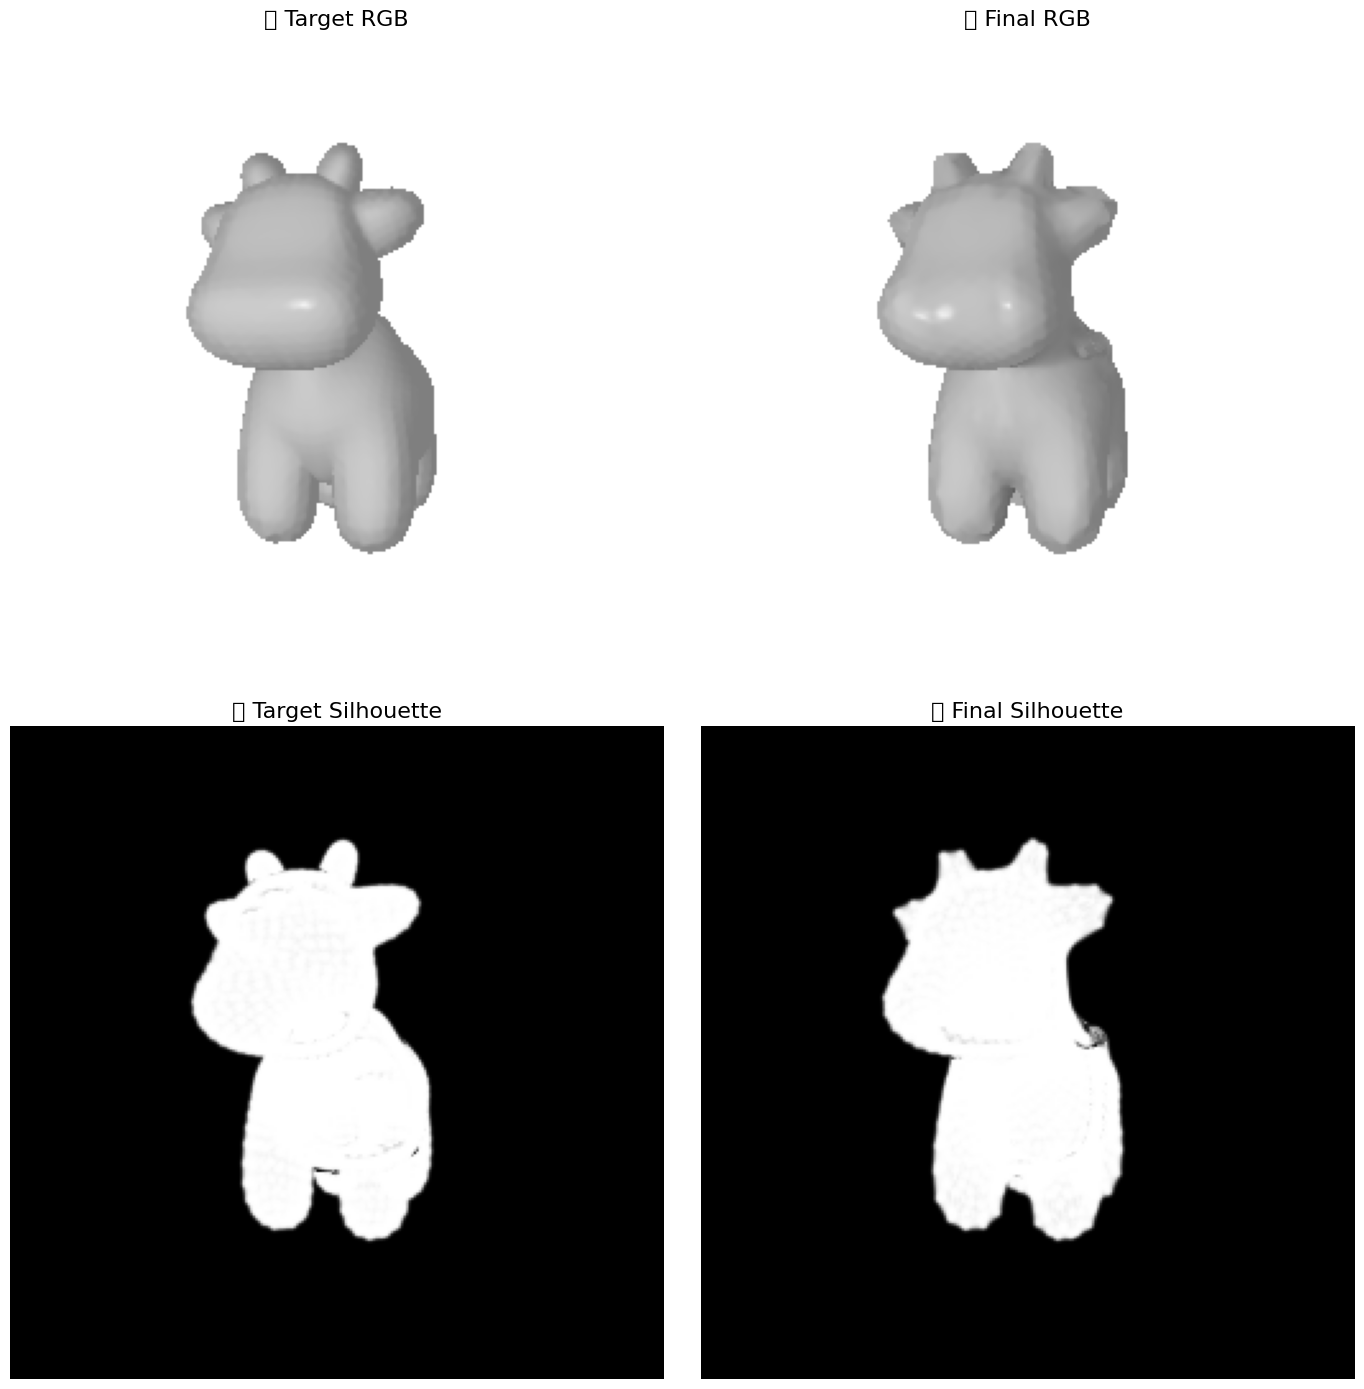

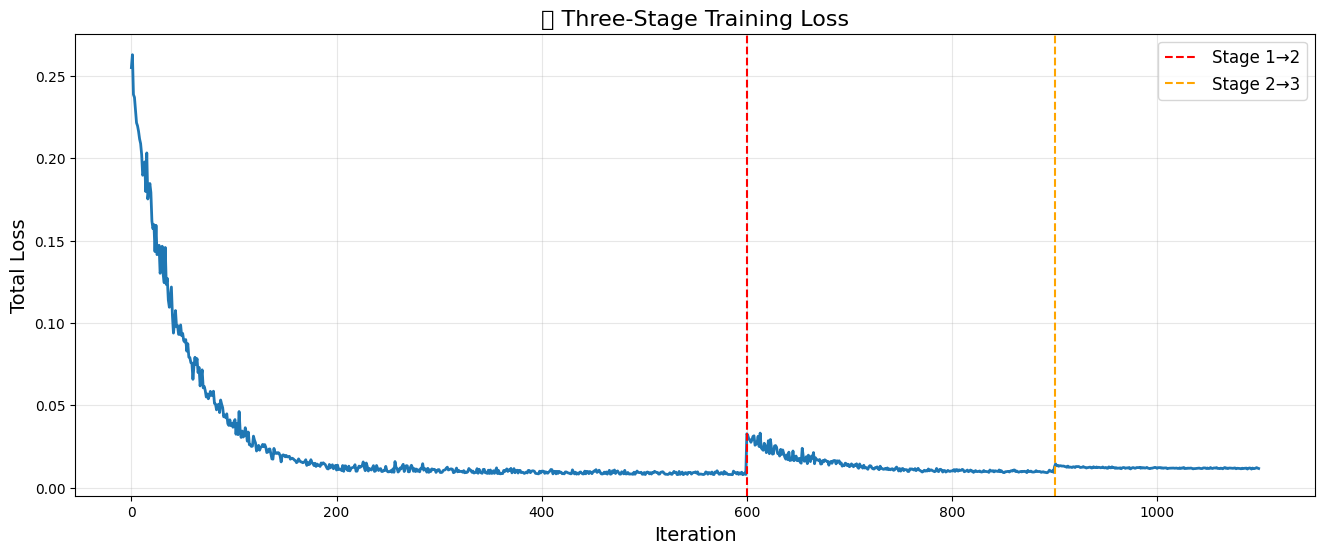

In [16]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output 

import pytorch3d
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import (
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency
)
from pytorch3d.renderer import (
    look_at_view_transform, 
    FoVPerspectiveCameras,
    PointLights,
    RasterizationSettings, 
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    TexturesVertex
)

# ==================== 环境确认 ====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 当前运行设备: {device}")
print("="*60)

# ==================== 1. 加载目标模型 ====================
obj_path = "/mnt/workspace/.configs/code-server/extensions/ms-toolsai.jupyter-renderers-1.3.0-universal/cow.obj"  # 根据你的实际路径调整
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])
print(f"✅ 成功加载目标模型")

# ==================== 2. 渲染管线配置 ====================
num_views = 20
elevation = torch.zeros(num_views)
azimuth = torch.linspace(-180, 180, num_views)
R, T = look_at_view_transform(dist=2.7, elev=elevation, azim=azimuth)

cameras = FoVPerspectiveCameras(device=device, R=R, T=T)
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=256,
    blur_radius=np.log(1./1e-4 - 1.)*sigma,
    faces_per_pixel=50,
    perspective_correct=False
)

renderer_rgb = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftPhongShader(device=device, cameras=cameras, lights=lights)
)

renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings_soft),
    shader=SoftSilhouetteShader()
)

# ==================== 3. 生成目标数据 ====================
print("🎨 生成目标数据...")
verts_rgb_white = torch.ones_like(verts).unsqueeze(0)
cow_mesh.textures = TexturesVertex(verts_features=verts_rgb_white)

target_rgb_images = renderer_rgb(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_rgb = [target_rgb_images[i, ..., :3] for i in range(num_views)]

target_silhouette_images = renderer_silhouette(cow_mesh.extend(num_views), cameras=cameras, lights=lights)
target_silhouette = [target_silhouette_images[i, ..., 3] for i in range(num_views)]

print(f"✅ 已生成目标数据")

# ==================== 4. 初始化源模型 ====================
src_mesh = ico_sphere(4, device)
verts_shape = src_mesh.verts_packed().shape

deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# ==================== 5. 三阶段训练配置 ====================
stage1_epochs = 600   # 阶段1：粗糙形状
stage2_epochs = 300   # 阶段2：形状+纹理
stage3_epochs = 200   # 阶段3：精细调整
total_epochs = stage1_epochs + stage2_epochs + stage3_epochs

num_views_per_iteration = 2

loss_history = {
    'total': [], 'rgb': [], 'silhouette': [], 
    'laplacian': [], 'edge': [], 'normal': []
}

output_dir = "output_meshes_textured_v3"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 模型保存目录: ./{output_dir}/")
print("="*60)
print("🔷 阶段1: 粗糙形状 (0-599)")
print("🔶 阶段2: 形状+纹理 (600-899)")
print("🔸 阶段3: 精细调整 (900-1099)")
print("="*60 + "\n")

# ==================== 6. 阶段1：粗糙形状 ====================
print("🔷 阶段1：粗糙形状拟合...")
optimizer_s1 = torch.optim.Adam([deform_verts], lr=0.01)
scheduler_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s1, T_max=stage1_epochs)

for i in range(stage1_epochs):
    optimizer_s1.zero_grad()
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]
    
    for j in selected_views:
        silhouette_predicted = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        loss_silhouette = ((silhouette_predicted[0, ..., 3] - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / num_views_per_iteration
    
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    loss = 1.0 * loss_silhouette_sum + 1.0 * loss_lap + 1.0 * loss_edge_loss + 0.01 * loss_norm
    
    loss.backward()
    optimizer_s1.step()
    scheduler_s1.step()
    
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(0.0)
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    if i % 50 == 0 or i == stage1_epochs - 1:
        clear_output(wait=True)
        print(f"🔷 阶段1 - Epoch {i:03d}/{stage1_epochs} | Loss: {loss.item():.6f} | Silhouette: {loss_silhouette_sum.item():.6f}")
        
        if i % 100 == 0 or i == stage1_epochs - 1:
            save_path = os.path.join(output_dir, f"s1_epoch_{i:04d}.obj")
            save_obj(save_path, new_src_mesh.verts_list()[0], new_src_mesh.faces_list()[0])

print("✅ 阶段1完成\n")

# ==================== 7. 阶段2：形状+纹理 ====================
print("🔶 阶段2：形状+纹理优化...")
optimizer_s2 = torch.optim.Adam([deform_verts, sphere_verts_rgb], lr=0.005)
scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s2, T_max=stage2_epochs)

for i in range(stage2_epochs):
    optimizer_s2.zero_grad()
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb)
    
    loss_rgb_sum = torch.tensor(0.0, device=device)
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    selected_views = np.random.permutation(num_views).tolist()[:num_views_per_iteration]
    
    for j in selected_views:
        images_pred = renderer_rgb(
            new_src_mesh, 
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        loss_rgb = ((images_pred[0, ..., :3] - target_rgb[j]) ** 2).mean()
        loss_rgb_sum += loss_rgb / num_views_per_iteration
        
        sil_pred = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        loss_silhouette = ((sil_pred[0, ..., 3] - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / num_views_per_iteration
    
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    loss = 1.0 * loss_rgb_sum + 2.0 * loss_silhouette_sum + 1.0 * loss_lap + 1.0 * loss_edge_loss + 0.01 * loss_norm
    
    loss.backward()
    optimizer_s2.step()
    scheduler_s2.step()
    
    epoch_num = stage1_epochs + i
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(loss_rgb_sum.item())
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    if i % 50 == 0 or i == stage2_epochs - 1:
        clear_output(wait=True)
        print(f"🔶 阶段2 - Epoch {epoch_num:04d}/{total_epochs} | Loss: {loss.item():.6f} | RGB: {loss_rgb_sum.item():.6f} | Sil: {loss_silhouette_sum.item():.6f}")
        
        if i % 100 == 0 or i == stage2_epochs - 1:
            save_path = os.path.join(output_dir, f"s2_epoch_{epoch_num:04d}.obj")
            save_obj(save_path, new_src_mesh.verts_list()[0], new_src_mesh.faces_list()[0])

print("✅ 阶段2完成\n")

# ==================== 8. 阶段3：精细调整 ====================
print("🔸 阶段3：精细调整...")
# 🔥 阶段3：更小学率，更多视角，更强正则化
optimizer_s3 = torch.optim.Adam([deform_verts, sphere_verts_rgb], lr=0.001)
scheduler_s3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_s3, T_max=stage3_epochs)

for i in range(stage3_epochs):
    optimizer_s3.zero_grad()
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb)
    
    loss_rgb_sum = torch.tensor(0.0, device=device)
    loss_silhouette_sum = torch.tensor(0.0, device=device)
    # 🔥 阶段3：使用更多视角 (4个)
    selected_views = np.random.permutation(num_views).tolist()[:4]
    
    for j in selected_views:
        images_pred = renderer_rgb(
            new_src_mesh, 
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        loss_rgb = ((images_pred[0, ..., :3] - target_rgb[j]) ** 2).mean()
        loss_rgb_sum += loss_rgb / 4
        
        sil_pred = renderer_silhouette(
            new_src_mesh,
            cameras=FoVPerspectiveCameras(device=device, R=R[None, j, ...], T=T[None, j, ...]),
            lights=lights
        )
        loss_silhouette = ((sil_pred[0, ..., 3] - target_silhouette[j]) ** 2).mean()
        loss_silhouette_sum += loss_silhouette / 4
    
    loss_lap = mesh_laplacian_smoothing(new_src_mesh, method="uniform")
    loss_edge_loss = mesh_edge_loss(new_src_mesh)
    loss_norm = mesh_normal_consistency(new_src_mesh)
    
    # 🔥 阶段3：增强正则化，防止过拟合
    loss = 1.0 * loss_rgb_sum + 2.0 * loss_silhouette_sum + 1.5 * loss_lap + 1.2 * loss_edge_loss + 0.02 * loss_norm
    
    loss.backward()
    optimizer_s3.step()
    scheduler_s3.step()
    
    epoch_num = stage1_epochs + stage2_epochs + i
    loss_history['total'].append(loss.item())
    loss_history['rgb'].append(loss_rgb_sum.item())
    loss_history['silhouette'].append(loss_silhouette_sum.item())
    loss_history['laplacian'].append(loss_lap.item())
    loss_history['edge'].append(loss_edge_loss.item())
    loss_history['normal'].append(loss_norm.item())
    
    if i % 20 == 0 or i == stage3_epochs - 1:
        clear_output(wait=True)
        print(f"🔸 阶段3 - Epoch {epoch_num:04d}/{total_epochs} | Loss: {loss.item():.6f} | RGB: {loss_rgb_sum.item():.6f} | Sil: {loss_silhouette_sum.item():.6f}")
        
        save_path = os.path.join(output_dir, f"s3_epoch_{epoch_num:04d}.obj")
        save_obj(save_path, new_src_mesh.verts_list()[0], new_src_mesh.faces_list()[0])

# ==================== 完成 ====================
print("\n" + "="*60)
print("🎉 三阶段优化完成！")
print(f"📁 模型: {output_dir}/")
print(f"📊 最终 RGB Loss: {loss_history['rgb'][-1]:.6f}")
print(f"📊 最终 Silhouette Loss: {loss_history['silhouette'][-1]:.6f}")
print("="*60)

# 最终可视化
with torch.no_grad():
    final_rgb = renderer_rgb(new_src_mesh, cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]), lights=lights)
    final_sil = renderer_silhouette(new_src_mesh, cameras=FoVPerspectiveCameras(device=device, R=R[None, 1, ...], T=T[None, 1, ...]), lights=lights)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(target_rgb[1].cpu().numpy())
axes[0, 0].set_title("🎯 Target RGB", fontsize=16)
axes[0, 0].axis("off")

axes[0, 1].imshow(final_rgb[0, ..., :3].cpu().numpy())
axes[0, 1].set_title("✨ Final RGB", fontsize=16)
axes[0, 1].axis("off")

axes[1, 0].imshow(target_silhouette[1].cpu().numpy(), cmap='gray')
axes[1, 0].set_title("🎯 Target Silhouette", fontsize=16)
axes[1, 0].axis("off")

axes[1, 1].imshow(final_sil[0, ..., 3].cpu().numpy(), cmap='gray')
axes[1, 1].set_title("✨ Final Silhouette", fontsize=16)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Loss曲线
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.plot(loss_history['total'], linewidth=2)
ax.axvline(x=stage1_epochs, color='red', linestyle='--', label='Stage 1→2')
ax.axvline(x=stage1_epochs+stage2_epochs, color='orange', linestyle='--', label='Stage 2→3')
ax.set_xlabel('Iteration', fontsize=14)
ax.set_ylabel('Total Loss', fontsize=14)
ax.set_title('📈 Three-Stage Training Loss', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()